# `kamo.trap` — from beams to a BEC density

Beam geometry → trap potential → condensate density, on the *real* potential:
anharmonic, gravity-tilted, evaluated for a specific hyperfine state and field.

1. **Beams** — `Tweezer`, `LightSheet`, `Crossed`: lab-frame polarization and propagation direction, 3D intensity.
2. **The light shift** — state polarizability from UDel-portal matrix elements; why the *field direction* matters.
3. **The trap** — built from the measured 1 kHz radial frequency: sag, principal frequencies, and where the atoms actually escape.
4. **One axis, exactly** — the sinc-DVR bound-state spectrum of the vertical cut.
5. **The density** — the non-interacting ground state, then exact GP, visualized and compared.
6. **Into the light** — those clouds through the BPM: lensing, attenuation, and the imaging systematic.
7. **A crossed trap** — principal axes that are not lab axes.

Conventions: SI throughout; energies quoted as $E/h$ (Hz) or in µK; fields in Gauss.
Lab frame: $x$ is the tweezer (and probe) axis, $z$ is vertical and the quantization axis.

In [20]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

%load_ext autoreload
%autoreload 2

import kamo.constants as kc
from kamo.trap import (Tweezer, LightSheet, Trap, StatePolarizability, NonInteractingSolver,
                       solve, solve_all, comparison_table)
from kamo.trap import plotting as tplt

plt.rcParams.update({"figure.dpi": 110, "legend.fontsize": "small", "legend.frameon": False,
                     "axes.titlesize": "medium", "font.size": 9})
np.set_printoptions(precision=4, suppress=True)
warnings.filterwarnings("ignore", message="UDel portal unreachable")   # offline: bundled snapshot

# --- the K-team operating point ---------------------------------------------
STATE = (4, 0, 0.5, 1, -1)        # |F=1, mF=-1>
B_GAUSS, B_DIR = 520.594, (0, 0, 1)
WAIST, WAVELENGTH = 3.4e-6, 1064e-9
F_RADIAL = 1.0e3                  # measured radial trap frequency (Hz)
N_ATOMS = 1000

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Beams

A beam is specified by exactly one keyword from each of three groups — colour (`wavelength_m` | `frequency_Hz`),
size (`waist` | `NA` | `rayleigh_range` | `divergence_angle`) and strength (`power` | `peak_intensity`, or neither) —
plus a lab-frame `polarization` (complex 3-vector) and `propagation_direction`. Vectors are normalized and checked:
a polarization with a component along $k$ is rejected. Beams are immutable; `with_power`, `moved_to`, `rotated`
return new ones.

In [54]:
tw = Tweezer(waist=WAIST,
             wavelength_m=WAVELENGTH,
             propagation_direction=(1,0,0),
            polarization=(0, 1, 1j))   # circular, along +x
sheet = LightSheet(waist=(8e-6, 120e-6),
                   wavelength_m=1064e-9,
                   power=40.,
                   propagation_direction=(0, 0, 1),
                   polarization=(1, 0, 0),
                   transverse_axis=(1, 0, 0))                                  # thin axis vertical
print(tw)
print(sheet)
print(f"tweezer: zR = {tw.zR*1e6:.1f} um, NA = {tw.NA:.3f}")
print(f"sheet:   zR = ({sheet.rayleigh_range_u*1e6:.0f}, {sheet.rayleigh_range_v*1e6:.0f}) um "
      f"-- the thin axis diverges {(sheet.waist_v/sheet.waist_u)**2:.0f}x faster")

# try:
#     Tweezer(waist=WAIST, NA=0.2, wavelength_m=WAVELENGTH)
# except ValueError as err:
#     print("\nover-specified:", err)
# try:
#     Tweezer(waist=WAIST, wavelength_m=WAVELENGTH, polarization=(1, 0, 0))
# except ValueError as err:
#     print("not transverse:", str(err)[:90], "...")

Tweezer(w=3.4 um, lambda=1064.0 nm, P=0 W, k=[1.0, 0.0, 0.0])
LightSheet(w=(8, 120) um, lambda=1064.0 nm, P=40 W, k=[0.0, 0.0, 1.0])
tweezer: zR = 34.1 um, NA = 0.100
sheet:   zR = (189, 42518) um -- the thin axis diverges 225x faster


(<Figure size 528x440 with 2 Axes>,
 <Axes: title={'center': 'cut normal to $x$'}, xlabel='$y$  ($\\mu$m)', ylabel='$z$  ($\\mu$m)'>)

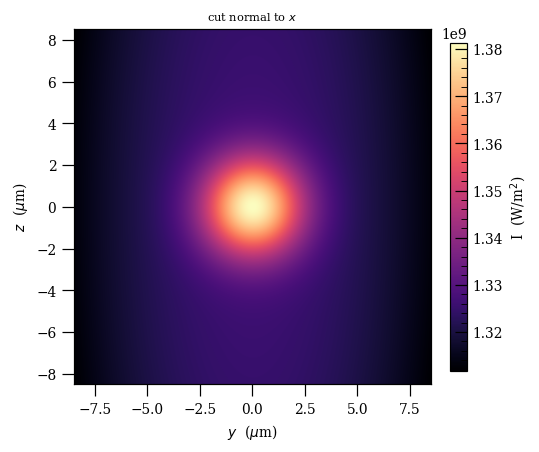

In [85]:
# fig, axes = plt.subplots(3,1, figsize=(5,10), layout="constrained")
# tplt.plot_beam_profile(sheet, ax=axes[0], title="light sheet: w_u(s), w_v(s)")
# tplt.plot_plane_cut(tw.with_power(43.65e-6), normal=(0, 1, 0), aspect='equal', title="tweezer, x-z plane")
tplt.plot_plane_cut(tw.with_power(1.e-3) + sheet.with_power(2.),
                    normal=(1.,0.,0),
                    aspect='auto',
                    n=(2000,2000))
# plt.ylim([-50,50])
# plt.xlim([-50,50])
# plt.show()

In [86]:
tplt.plot_line_cuts(tw.with_power(1.e-3)+sheet.with_power(2.),
                    directions=(0,0,1))

AttributeError: 'Crossed' object has no attribute 'minimum'

## 2. The light shift, and why the field direction matters

The AC Stark shift is $U = -\alpha I / (2 c \epsilon_0)$ with
$\alpha = \alpha_s - \beta\,\frac{m_F}{2F}\alpha_v + \gamma\,\frac{3m_F^2 - F(F+1)}{F(2F-1)}\alpha_t$.
The two geometry factors are computed **in the lab frame** from the beam polarization $\hat\epsilon$ and the
quantization axis $\hat B$: $\beta = \mathrm{Im}(\hat\epsilon\times\hat\epsilon^*)\cdot\hat B$ (circularity) and
$\gamma = (3|\hat\epsilon\cdot\hat B|^2 - 1)/2$ (alignment).

The matrix elements come from the UDel atomic-physics portal (measured D-line elements, with ARC filling in the
rest) plus the K⁺ core; every `StatePolarizability` reports where its numbers came from.

In [87]:
sp = StatePolarizability(STATE)                 # portal + ARC fill-in, K+ core, cached module-wide
a_s, a_v, a_t = sp.components_au(WAVELENGTH)
print(f"4S1/2 |1,-1> at 1064 nm: alpha_s = {a_s:.3f} a.u., alpha_v = {a_v:.3f} a.u. (alpha_t = 0 for j = 1/2)")
print(f"portal uncertainty on alpha_s: +- {sp.uncertainty_au(WAVELENGTH):.3f} a.u.")
print(sp.describe(WAVELENGTH))

# the same circular beam (0, 1, i) along x, two field directions
for bhat, label in (((0, 0, 1), "B along z (perpendicular to the beam)"), ((1, 0, 0), "B along x (along the beam)")):
    a_m = sp.alpha_au(WAVELENGTH, tw.polarization, bhat)
    a_p = sp.for_state((4, 0, 0.5, 1, +1)).alpha_au(WAVELENGTH, tw.polarization, bhat)
    print(f"{label:42s} alpha(mF=-1) = {a_m:8.3f}  alpha(mF=+1) = {a_p:8.3f} a.u.  "
          f"-> differential {a_p - a_m:+.3f} a.u.")

4S1/2 |1,-1> at 1064 nm: alpha_s = 599.301 a.u., alpha_v = 2.631 a.u. (alpha_t = 0 for j = 1/2)
portal uncertainty on alpha_s: +- 0.453 a.u.
polarizability: UDel portal (cache, fetched 2026-09-10) 18 transitions / 100.00% of alpha_s; ARC 8 / 0.00%
B along z (perpendicular to the beam)      alpha(mF=-1) =  599.301  alpha(mF=+1) =  599.301 a.u.  -> differential +0.000 a.u.
B along x (along the beam)                 alpha(mF=-1) =  597.985  alpha(mF=+1) =  600.616 a.u.  -> differential +2.631 a.u.


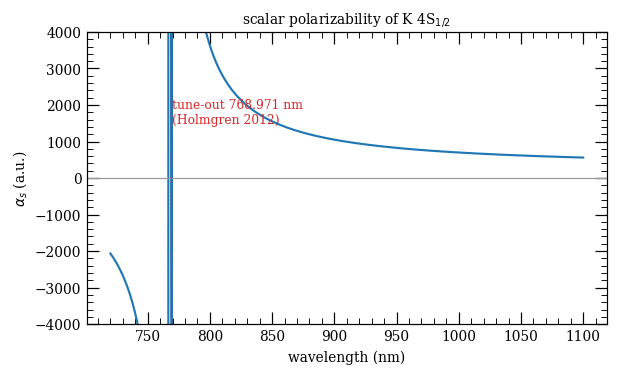

In [88]:
lam = np.linspace(720e-9, 1100e-9, 600)
alpha = np.array([sp.components_au(L)[0] for L in lam])
zero = lam[np.argmin(np.abs(alpha[(lam > 767e-9) & (lam < 770e-9)]))]

fig, ax = plt.subplots(figsize=(5.5, 3.3), layout="constrained")
ax.plot(lam * 1e9, alpha, lw=1.4)
ax.axhline(0, color="0.6", lw=0.8)
ax.axvline(768.9712, color="tab:red", ls=":", lw=0.9)
ax.annotate("tune-out 768.971 nm\n(Holmgren 2012)", (769.5, 1500), fontsize=8, color="tab:red")
ax.set_ylim(-4000, 4000)
ax.set_xlabel("wavelength (nm)"); ax.set_ylabel(r"$\alpha_s$ (a.u.)")
ax.set_title("scalar polarizability of K 4S$_{1/2}$")
plt.show()

## 3. The trap

`Trap(beams, state, B)` evaluates the potential, each beam with its own polarizability, plus gravity.
Nothing here needs a trap depth or a polarizability as input: the trap is specified by its geometry and then
scaled to the **measured** 1 kHz radial frequency. Everything else — the sagged minimum, the principal
frequencies (numerical Hessian), the escape depth — follows from $U(\mathbf r)$.

In [89]:
trap = Trap(tw, state=STATE, B_gauss=B_GAUSS, B_direction=B_DIR).rescaled_to_frequency(F_RADIAL)
print(trap.summary())
print(f"\npower for {F_RADIAL/1e3:.0f} kHz radial: {trap.field.power*1e6:.2f} uW")
print(f"principal frequencies: {trap.frequencies_Hz} Hz along\n{trap.principal_axes}")
print(f"sag: {trap.sag_along_gravity*1e9:.1f} nm  (harmonic estimate g/w^2 = "
      f"{9.80665/(2*np.pi*trap.frequencies_Hz[1])**2*1e9:.1f} nm)")

Trap: 1 beam(s), state (4, 0, 0.5, 1.0, -1.0), B = 520.6 G along [0.0, 0.0, 1.0], gravity on
  Tweezer(w=3.4 um, lambda=1064.0 nm, P=7.279e-05 W, k=[1.0, 0.0, 0.0]): alpha = 599.301 a.u.
  polarizability: UDel portal (cache, fetched 2026-09-10) 18 transitions / 100.00% of alpha_s; ARC 8 / 0.00%
  minimum at (+0.0000, +0.0000, -0.2484) um, U/h = -11.3785 kHz
  gravitational sag 248.41 nm
  principal frequencies 1000.000, 989.267, 70.060 Hz
  escape depth 6.0866 kHz = 0.2921 uK
  escape saddle at (-39.634, -0.000, -3.684) um

power for 1 kHz radial: 72.79 uW
principal frequencies: [1000.      989.2668   70.0595] Hz along
[[ 0. -1. -0.]
 [ 0. -0.  1.]
 [ 1.  0.  0.]]
sag: 248.4 nm  (harmonic estimate g/w^2 = 253.8 nm)


### Where the atoms leave

A 1D vertical cut through the focus has its escape lip straight below the trap — that is what a 1D model
(or the `gaussian_well` notebook) reports. In 3D the first-order saddle is elsewhere: about a Rayleigh range
*along the beam*, where the beam is weaker and wider, the gravity lip is lower. `trap_depth_J` finds that saddle
by Newton on $\nabla U = 0$; `escape_barrier_J(direction)` gives the barrier along any single ray.

barrier straight down:        6841.5 Hz  = 0.328 uK   (the 1D vertical cut)
3D escape depth (saddle):     6086.6 Hz  = 0.292 uK
saddle at (-39.6, -0.0, -3.68) um -- 1.16 zR along the beam, 11% below the vertical-cut number


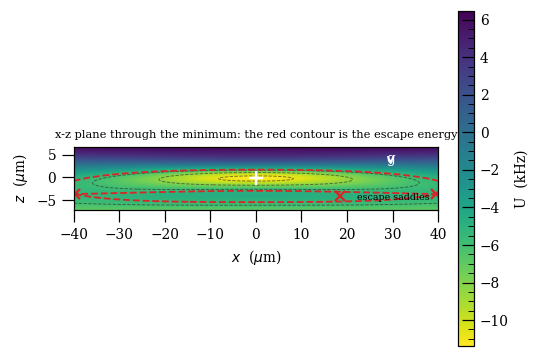

In [90]:
down = trap.escape_barrier_J([0, 0, -1])
s = trap.escape_saddle
print(f"barrier straight down:      {down/kc.h:8.1f} Hz  = {down/kc.kB*1e6:.3f} uK   (the 1D vertical cut)")
print(f"3D escape depth (saddle):   {trap.depth_Hz:8.1f} Hz  = {trap.depth_uK:.3f} uK")
print(f"saddle at ({s[0]*1e6:+.1f}, {s[1]*1e6:+.1f}, {s[2]*1e6:+.2f}) um -- {abs(s[0])/tw.zR:.2f} zR along the beam,"
      f" {100*(1 - trap.depth_J/down):.0f}% below the vertical-cut number")

fig, ax = tplt.plot_plane_cut(trap, normal=(0, 1, 0), half_width=(40e-6, 7e-6), n=(321, 121),
                              units="kHz", title="x-z plane through the minimum: the red contour is the escape energy")
ax.plot([s[0]*1e6, -s[0]*1e6], [s[2]*1e6, s[2]*1e6], "x", color="tab:red", ms=7, mew=1.5, label="escape saddles")
ax.legend(loc="lower right", fontsize="x-small")
plt.show()

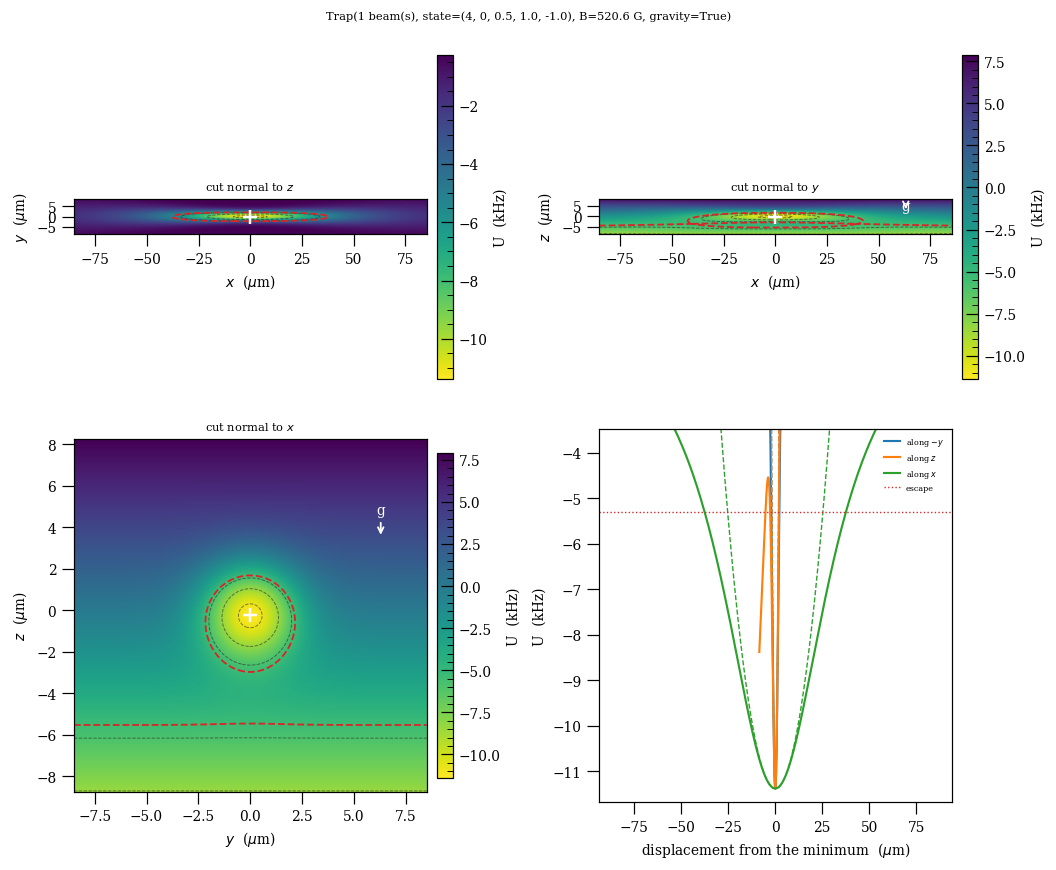

In [91]:
fig, axes = tplt.plot_trap_summary(trap, units="kHz")
plt.show()

## 4. One axis, exactly

`NonInteractingSolver.axis_spectra()` solves the 1D Schrödinger equation along each principal axis with a
sinc-DVR (spectrally accurate on a uniform grid). It reports the bound-state count, the level spacings against the
harmonic $\hbar\omega$, and — with gravity — the escape lip. The vertical radial cut is the interesting one.
The axial cut is a different well: its Lorentzian profile holds hundreds of states, and the top ones are limited by the finite box (the summary says how many were left unresolved) rather than by the trap.

In [92]:
ni = NonInteractingSolver(trap)
specs = ni.axis_spectra()
names = ["y (horizontal radial)", "z (vertical radial)", "x (axial)"]
for name, spec in zip(names, specs):
    print(f"--- {name}")
    print(spec.summary())

--- y (horizontal radial)
AxisSpectrum: 18 bound state(s)
  minimum      u = -0.0000 um,  V_min/h = -11.3785 kHz
  escape       over the box edge,  E_escape/h = -0.2379 kHz,  usable depth/h = 11.1407 kHz
  curvature    f = 1000.000 Hz at the minimum
  ground state (E_0 - V_min)/h = 491.570 Hz,  anharmonicity -0.843% of hbar omega
  spacings / hbar omega: 0.9659, 0.9312, 0.8956, 0.8590, 0.8215, ...
  sigma = 0.3664 um  (harmonic 0.3601 um)
--- z (vertical radial)
AxisSpectrum: 9 bound state(s)
  minimum      u = -0.0000 um,  V_min/h = -11.3785 kHz
  escape       lip at u = -3.770 um,  E_escape/h = -4.5370 kHz,  usable depth/h = 6.8415 kHz
  curvature    f = 989.267 Hz at the minimum
  ground state (E_0 - V_min)/h = 485.676 Hz,  anharmonicity -0.905% of hbar omega
  spacings / hbar omega: 0.9621, 0.9225, 0.8805, 0.8354, 0.7856, ...
  sigma = 0.3690 um  (harmonic 0.3621 um)
--- x (axial)
AxisSpectrum: 507 bound state(s), 44 unresolved at the box edge
  minimum      u = +0.0000 um,  V_min/

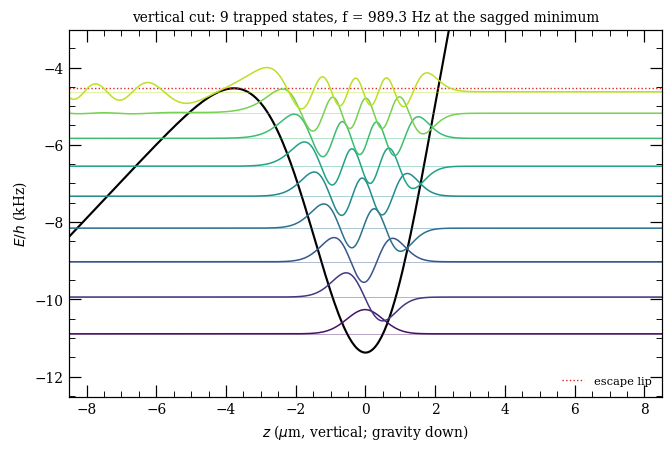

In [93]:
spec = specs[1]                                                   # the vertical cut
u_um, V_kHz, E_kHz = spec.u * 1e6, spec.V / kc.h / 1e3, spec.bound_energies / kc.h / 1e3
fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
ax.plot(u_um, V_kHz, "k", lw=1.4)
ax.axhline(spec.E_escape / kc.h / 1e3, color="tab:red", ls=":", lw=0.9, label="escape lip")
spacing = np.mean(np.diff(E_kHz))
cols = plt.cm.viridis(np.linspace(0.05, 0.9, spec.n_bound))
for n in range(spec.n_bound):
    psi = spec.psi[:, n]
    ax.plot(u_um, E_kHz[n] + 0.8 * spacing * psi / np.abs(psi).max(), color=cols[n], lw=1)
    ax.axhline(E_kHz[n], color=cols[n], lw=0.5, alpha=0.5)
ax.set_xlim(-2.5 * WAIST * 1e6, 2.5 * WAIST * 1e6)
ax.set_ylim(1.1 * V_kHz.min(), spec.E_escape / kc.h / 1e3 + 1.5)
ax.set_xlabel(r"$z$ ($\mu$m, vertical; gravity down)"); ax.set_ylabel(r"$E/h$ (kHz)")
ax.set_title(f"vertical cut: {spec.n_bound} trapped states, f = {spec.frequency_Hz:.1f} Hz at the sagged minimum")
ax.legend(loc="lower right")
plt.show()

## 5. The density: the non-interacting ground state, then exact GP

`solve(trap, N, mode)` returns a `TrapCloud` from any of the three modes, all on the real potential:

* **noninteracting** — the 3D single-particle ground state (tensor-product sinc-DVR, LOBPCG), $N$ atoms placed in it;
* **thomas-fermi** — $n = \max(0, (\mu - V)/g)$, kinetic energy dropped;
* **gp** — the Gross-Pitaevskii ground state (imaginary time, then a conjugate-gradient polish to a residual below $10^{-8}$).

The reference row is the harmonic Gaussian: the variational cloud in the *harmonic approximation* of this trap,
which is what `kamo` used before. The scattering length for $|1,-1\rangle$ at 520.6 G comes from `kamo.scattering`.

In [94]:
from kamo.BEC_properties.variational import GaussianVariationalCloud

clouds = solve_all(trap, N_ATOMS, options={"gp": dict(points_per_scale=3.0)})
ni_cloud, tf, gp = clouds["noninteracting"], clouds["thomas-fermi"], clouds["gp"]

# the harmonic reference, along LAB axes: this trap's Hessian is diagonal in the lab frame
H = trap.hessian(trap.minimum_position)
omega_lab = np.sqrt(np.diag(H) / trap.mass)
var = GaussianVariationalCloud(N_ATOMS, omega_lab, gp.a_scattering, mass=trap.mass)
clouds["harmonic Gaussian"] = var

print(f"a = {gp.a_scattering / kc.a0:+.2f} a0,   Thomas-Fermi valid here: {gp.thomas_fermi_valid},"
      f"   healing length {gp.healing_length*1e6:.3f} um\n")
print(comparison_table(clouds, axes=np.eye(3)))   # var is already lab-ordered

a = +10.97 a0,   Thomas-Fermi valid here: False,   healing length 0.636 um

mode                  (mu-Vmin)/h Hz    n0 cm^-3  column cm^-2          sigma x,y,z (um)
noninteracting               1004.38   3.208e+14     1.142e+11   1.3972  0.3692  0.3718
thomas-fermi                  526.60   2.783e+14     2.809e+11   2.8876  0.2000  0.2024
gp                           1148.38   1.692e+14     1.046e+11   2.1655  0.3827  0.3857
harmonic Gaussian            1189.71   2.131e+14     1.136e+11   2.1271  0.3732  0.3754


In [95]:
print(ni_cloud.summary(), "\n")
print(gp.summary())
print(f"\ninteractions push mu up by {gp.chemical_potential_offset/ni_cloud.chemical_potential_offset:.2f}x"
      f" and the cloud out by {gp.sigma[0]/ni_cloud.sigma[0]:.2f}x axially,"
      f" {gp.sigma[2]/ni_cloud.sigma[2]:.2f}x vertically")

TrapCloud (noninteracting): N = 1000, a = +0.000 a0
  grid TrapGrid(40x40x40, +-(10.5, 2.77, 2.79) um), normalization error -1.1e-16
  (mu - V_min)/h = 1004.381 Hz, (E/N - V_min)/h = 1004.381 Hz
  centroid (-0.0000, +0.0000, -0.2744) um, sigma (1.3972, 0.3692, 0.3718) um
  n0 = 3.2084e+14 cm^-3, peak column 1.1415e+11 cm^-2 

TrapCloud (gp): N = 1000, a = +10.969 a0
  grid TrapGrid(192x50x50, +-(17.7, 3.11, 3.12) um), normalization error +2.2e-16
  (mu - V_min)/h = 1148.384 Hz, (E/N - V_min)/h = 1084.848 Hz
  centroid (+0.0000, +0.0000, -0.2777) um, sigma (2.1655, 0.3827, 0.3857) um
  n0 = 1.6924e+14 cm^-3, peak column 1.0458e+11 cm^-2
  healing length 0.6364 um, Thomas-Fermi NOT valid here

interactions push mu up by 1.14x and the cloud out by 1.55x axially, 1.04x vertically


### Visualizing the two

Column density along $x$ (the probe axis) — what an image would see — and cuts through the centre.
The non-interacting cloud is the ground state of the well; the GP cloud is pushed outward by the mean field,
most visibly along the weak axial direction.

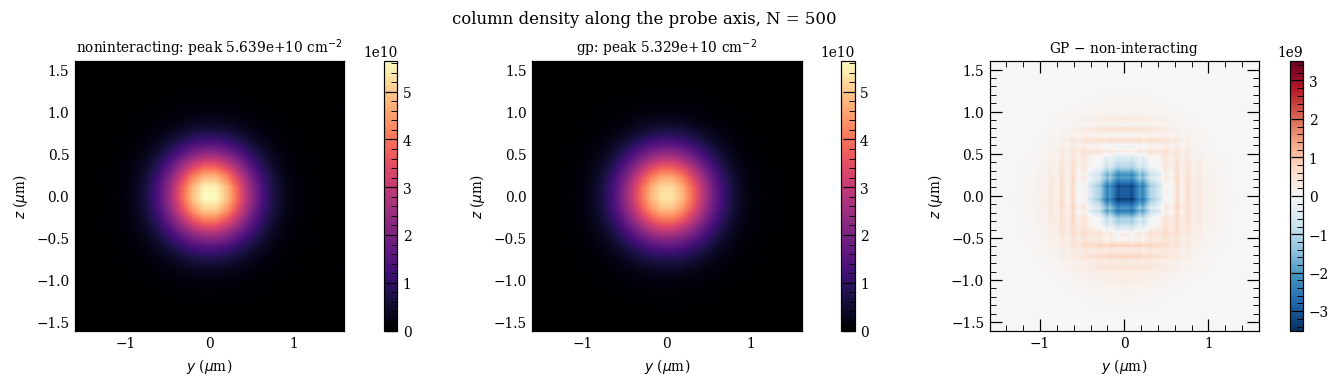

In [ ]:
c = gp.centroid
y = np.linspace(-1.6e-6, 1.6e-6, 201)
z = np.linspace(-1.6e-6, 1.6e-6, 201)
Y, Z = np.meshgrid(y, z, indexing="ij")
ncol = {k: clouds[k].column_density(Y + c[1], Z + c[2]) * 1e-4          # cm^-2
        for k in ("noninteracting", "gp")}
vmax = max(m.max() for m in ncol.values())

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4), layout="constrained")
ext = [y[0]*1e6, y[-1]*1e6, z[0]*1e6, z[-1]*1e6]
for ax, key in zip(axes, ("noninteracting", "gp")):
    im = ax.imshow(ncol[key].T, extent=ext, origin="lower", cmap="magma", vmin=0, vmax=vmax)
    ax.set_title(f"{key}: peak {ncol[key].max():.3e} cm$^{{-2}}$")
    ax.set_xlabel(r"$y$ ($\mu$m)"); ax.set_ylabel(r"$z$ ($\mu$m)")
    fig.colorbar(im, ax=ax, fraction=0.046)
d = ncol["gp"] - ncol["noninteracting"]
im = axes[2].imshow(d.T, extent=ext, origin="lower", cmap="RdBu_r",
                    vmin=-np.abs(d).max(), vmax=np.abs(d).max())
axes[2].set_title("GP $-$ non-interacting")
axes[2].set_xlabel(r"$y$ ($\mu$m)"); axes[2].set_ylabel(r"$z$ ($\mu$m)")
fig.colorbar(im, ax=axes[2], fraction=0.046)
fig.suptitle(f"column density along the probe axis, N = {N_ATOMS}")
plt.show()

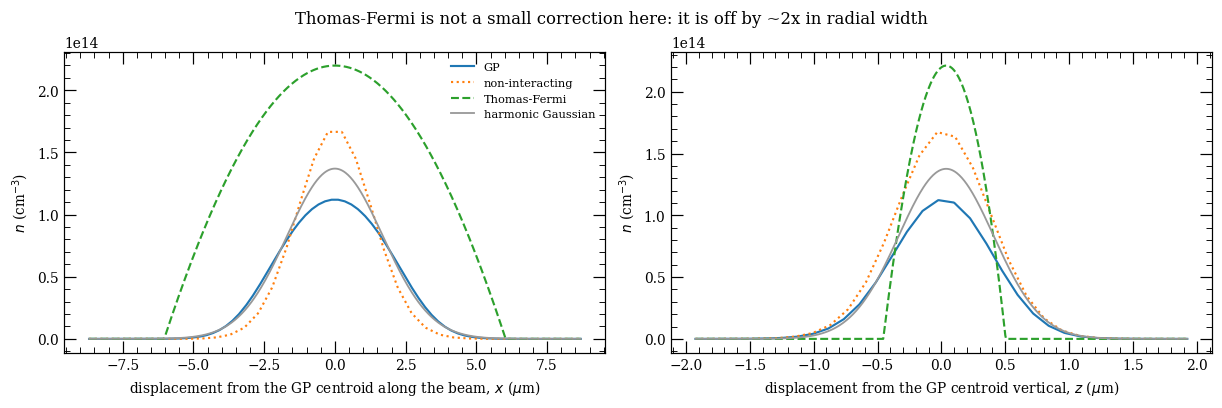

In [ ]:
R = trap.principal_axes
m0 = trap.minimum_position
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), layout="constrained")
for ax, (axis, label) in zip(axes, ((0, "along the beam, $x$"), (2, "vertical, $z$"))):
    s = np.linspace(-1, 1, 601) * (5.0 * gp.sigma[axis])
    r = [np.full_like(s, c[0]), np.full_like(s, c[1]), np.full_like(s, c[2])]
    r[axis] = c[axis] + s
    for cl, name, ls in ((gp, "GP", "-"), (ni_cloud, "non-interacting", ":"),
                         (tf, "Thomas-Fermi", "--")):
        ax.plot(s * 1e6, cl.density(*r) * 1e-6, ls, label=name, lw=1.4)
    # the harmonic Gaussian sits at the trap minimum and knows nothing of the anharmonicity
    p = [r[k] - m0[k] for k in range(3)]
    ax.plot(s * 1e6, var.density(*p) * 1e-6, "-", color="0.6", lw=1.2, label="harmonic Gaussian")
    ax.set_xlabel(f"displacement from the GP centroid {label} " + r"($\mu$m)")
    ax.set_ylabel(r"$n$ (cm$^{-3}$)")
axes[0].legend()
fig.suptitle("Thomas-Fermi is not a small correction here: it is off by ~2x in radial width")
plt.show()

## 6. Into the light: lensing and attenuation

The cloud is a **phase object**, and at this density a strong one: the probe focuses inside it rather than
simply being absorbed. `kamo.imaging` propagates the field slice by slice (BPM) through the real density,
and `GriddedMixture` is the adapter that lets any `TrapCloud` stand where the analytic Gaussian used to.

The probe is the measured two-transition K-39 probe at 520.6 G, tuned to the midpoint, with all atoms in
$|{\rm up}\rangle$.

In [96]:
from kamo import Potassium39
from kamo.imaging import ProbeBeam, Propagator, UniformMixture, readout
from kamo.imaging import plotting as iplt
from kamo.trap.imaging_bridge import GriddedMixture

atom = Potassium39()
probe = ProbeBeam.from_midpoint(
    atom, B_gauss=B_GAUSS,
    ground_up=(4, 0, 1/2, -1/2, -1/2), excited_up=(4, 1, 3/2, -3/2, -1/2),
    ground_dn=(4, 0, 1/2, -1/2, +1/2), excited_dn=(4, 1, 3/2, -3/2, +1/2))
probe = ProbeBeam.from_offresonant_saturation(probe, 0.001, which="up")
response, species = probe.response, probe.species(xi=1.0)
print(probe.summary())

D, phi = response.thin_screen(gp.peak_column_density, species)
print(f"\nthin screen on the GP peak column: D = {D:.4f} (attenuation), phi = {phi:+.3f} rad (lensing)")
print(f"cloud length {2*gp.widths[0]*1e6:.1f} um vs k w_perp^2 = "
      f"{response.k*gp.widths[1]**2*1e6:.1f} um -> the light diffracts INSIDE the cloud: "
      f"a thin screen will not do")

ProbeBeam  f = 391.015487 THz (+0.000 MHz from midpoint)
  |up>  f = 391.015432 THz, Delta =  +55.117 MHz -> delta =  +18.278
  |dn>  f = 391.015542 THz, Delta =  -55.117 MHz -> delta =  -18.278
  splitting S = 110.2347 MHz  (at midpoint: delta_dn = -delta_up)
  incident s0 = 0.3351, differential light shift = -55.062 kHz
  TwoLevelResponse(lambda=766.7022 nm, Gamma/2pi=6.0309 MHz, sigma0=2.806692e-13 m^2)

thin screen on the GP peak column: D = 0.8759 (attenuation), phi = -8.005 rad (lensing)
cloud length 6.1 um vs k w_perp^2 = 2.4 um -> the light diffracts INSIDE the cloud: a thin screen will not do


In [97]:
NA = 0.42
prop = Propagator.for_cloud(response, gp, n_grid=512, L_box=24e-6, n_slices=150)

def image_cloud(cloud):
    # propagate one cloud and read the camera plane out of it
    source = (GriddedMixture.for_propagator(prop, cloud, response, species)
              if hasattr(cloud, "density_grid") else
              UniformMixture(cloud, response, species))
    res = prop.propagate(source, s0_incident=probe.s0_incident, record="plane")
    psi = readout.refocus(res)
    return res, psi, readout.phase_contrast(psi, res.grid, NA=NA)

runs = {name: image_cloud(clouds[name])
        for name in ("noninteracting", "gp", "harmonic Gaussian")}

print(f"{'cloud':<20}{'phase (rad)':>13}{'on-axis D':>12}{'min |psi|^2':>13}"
      f"{'peak I/I0 inside':>18}{'PCI signal':>12}")
for name, (res, psi, img) in runs.items():
    print(f"{name:<20}{readout.recovered_phase(psi, res.grid):>13.3f}"
          f"{readout.optical_depth(psi):>12.3f}{np.abs(psi).min()**2:>13.3f}"
          f"{res.intensity_plane.max():>18.2f}{readout.signal_on_axis(img):>12.3f}")
I_peak = runs["gp"][0].intensity_plane.max()
print()
print(f"The thin screen predicted {phi:+.2f} rad; the BPM recovers a fraction of that, because")
print("the cloud is longer than the Rayleigh range of its own transverse structure -- the")
print("imprinted phase diffracts before it reaches the exit plane.  The lens is real all the")
print(f"same: the probe reaches {I_peak:.2f} I0 inside the cloud.  The on-axis optical depth")
print("stays positive, so the shadow is still a shadow, not the bright spot a stronger lens makes.")

cloud                 phase (rad)   on-axis D  min |psi|^2  peak I/I0 inside  PCI signal
noninteracting             -2.920       3.252        0.039              1.60       0.835
gp                         -1.807       1.709        0.181              1.47       0.550
harmonic Gaussian          -1.871       1.966        0.140              1.48       0.535

The thin screen predicted -8.01 rad; the BPM recovers a fraction of that, because
the cloud is longer than the Rayleigh range of its own transverse structure -- the
imprinted phase diffracts before it reaches the exit plane.  The lens is real all the
same: the probe reaches 1.47 I0 inside the cloud.  The on-axis optical depth
stays positive, so the shadow is still a shadow, not the bright spot a stronger lens makes.


### Lensing: the probe intensity as it crosses the cloud

Red is more light than the bare probe, blue less. The GP cloud is wider and less dense at its centre than the
harmonic Gaussian, so it is a *weaker* lens — the focus it forms is softer and sits further downstream.

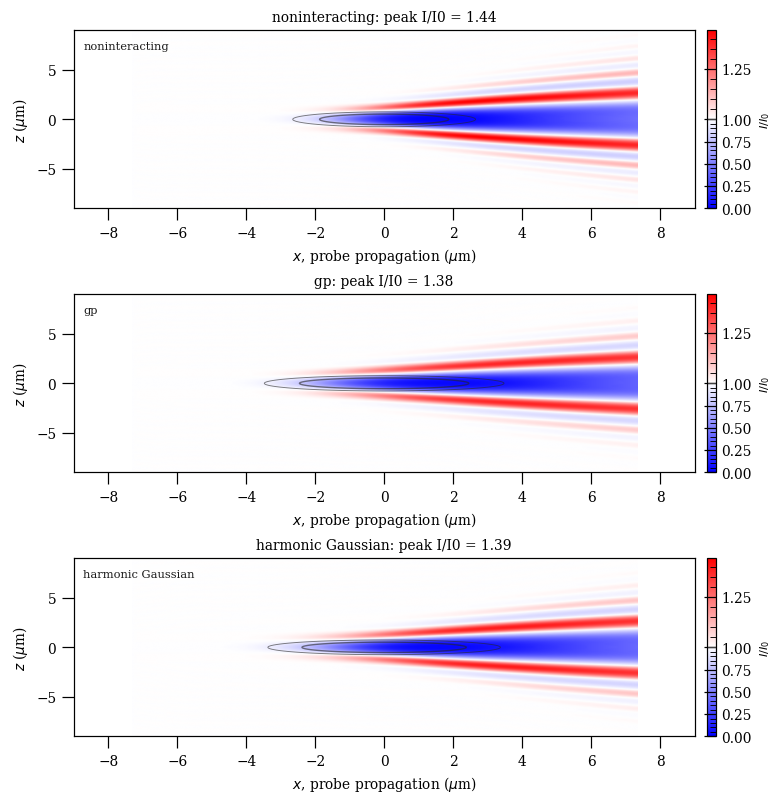

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(7, 7.2), layout="constrained")
vmax = max(r.intensity_plane.max() for r, _, _ in runs.values())
for ax, (name, (res, psi, img)) in zip(axes, runs.items()):
    iplt.plot_intensity_xz(res, z_half=2.0e-6, ax=ax, vmax=vmax, waist=WAIST,
                           label=name, cbar=True)
    ax.set_title(f"{name}: peak I/I0 = {res.intensity_plane.max():.2f}")
plt.show()

### Attenuation and phase at the camera

Transmission $|\psi|^2$, the wrapped exit phase, and the phase-contrast image, all refocused onto the cloud.
Transmission below 1 is attenuation; above 1 is light the lens moved there.

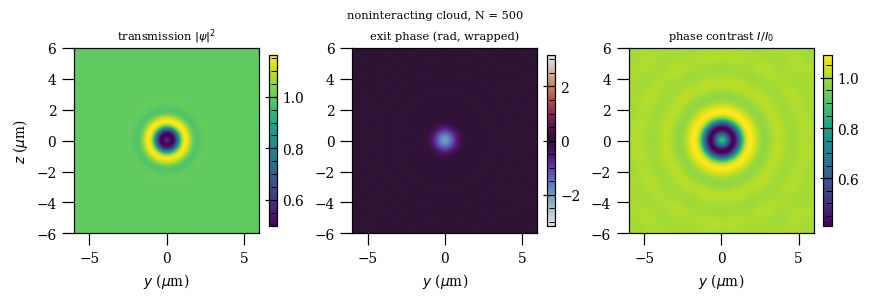

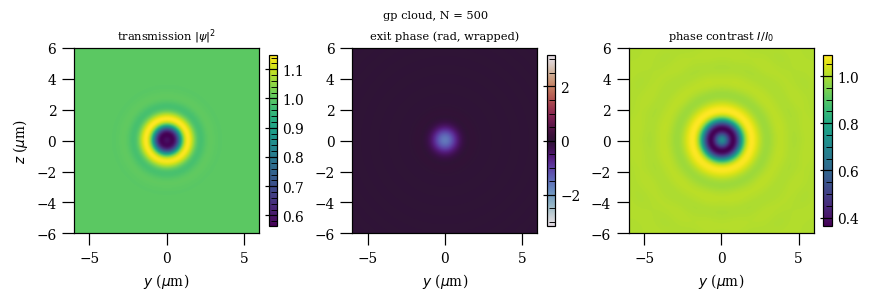

In [ ]:
for name in ("noninteracting", "gp"):
    res, psi, img = runs[name]
    fig, axes = iplt.plot_exit_wave(psi, res.grid, image=img, waist=WAIST, n_waists=2.0,
                                    title=f"{name} cloud, N = {N_ATOMS}")
    plt.show()

In [ ]:
(_, psi_gp, img_gp), (_, psi_var, img_var) = runs["gp"], runs["harmonic Gaussian"]
s_gp, s_var = readout.signal_on_axis(img_gp), readout.signal_on_axis(img_var)
ph_gp = readout.recovered_phase(psi_gp, runs["gp"][0].grid)
ph_var = readout.recovered_phase(psi_var, runs["harmonic Gaussian"][0].grid)
print(f"peak column density   GP / harmonic Gaussian = {gp.peak_column_density / var.peak_column_density:.3f}")
print(f"recovered phase       GP / harmonic Gaussian = {ph_gp / ph_var:.3f}")
print(f"phase-contrast signal GP / harmonic Gaussian = {s_gp / s_var:.3f}")
print()
print("The recovered phase tracks the peak column density: a cloud less dense at its centre")
print("imprints less phase.  The phase-contrast signal does not follow it -- here it is LARGER")
print("in magnitude for the GP cloud -- because the on-axis PCI pixel is set by the whole")
print("transverse profile seen through the lens, not by the peak alone.  Either way, an atom")
print("number calibrated on a harmonic-Gaussian cloud carries the section-5 density bias.")

peak column density   GP / harmonic Gaussian = 0.917
recovered phase       GP / harmonic Gaussian = 0.943
phase-contrast signal GP / harmonic Gaussian = 1.110

The recovered phase tracks the peak column density: a cloud less dense at its centre
imprints less phase.  The phase-contrast signal does not follow it -- here it is LARGER
in magnitude for the GP cloud -- because the on-axis PCI pixel is set by the whole
transverse profile seen through the lens, not by the peak alone.  Either way, an atom
number calibrated on a harmonic-Gaussian cloud carries the section-5 density bias.


## 7. A crossed trap

Two tweezers at ±45° in the horizontal plane, at different wavelengths so their intensities add incoherently
(`Crossed` warns if two beams could interfere). The principal axes of the Hessian are not lab axes; each beam
carries its own polarizability.

Trap: 2 beam(s), state (4, 0, 0.5, 1.0, -1.0), B = 520.6 G along [0.0, 0.0, 1.0], gravity on
  Tweezer(w=3 um, lambda=1064.0 nm, P=5e-05 W, k=[1.0, 0.0, 0.0], label='1064'): alpha = 599.301 a.u.
  Tweezer(w=2 um, lambda=1070.0 nm, P=5e-05 W, k=[0.0, 1.0, 0.0], label='1070'): alpha = 592.179 a.u.
  polarizability: UDel portal (cache, fetched 2026-09-10) 18 transitions / 100.00% of alpha_s; ARC 8 / 0.00%
  minimum at (+0.0000, +0.0000, -0.0362) um, U/h = -32.0397 kHz
  gravitational sag 36.15 nm
  principal frequencies 2619.723, 2394.433, 1108.178 Hz
  escape depth 27.3891 kHz = 1.3145 uK
  escape saddle at (+0.000, -24.188, -3.238) um

principal axes (rows):
 [[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]


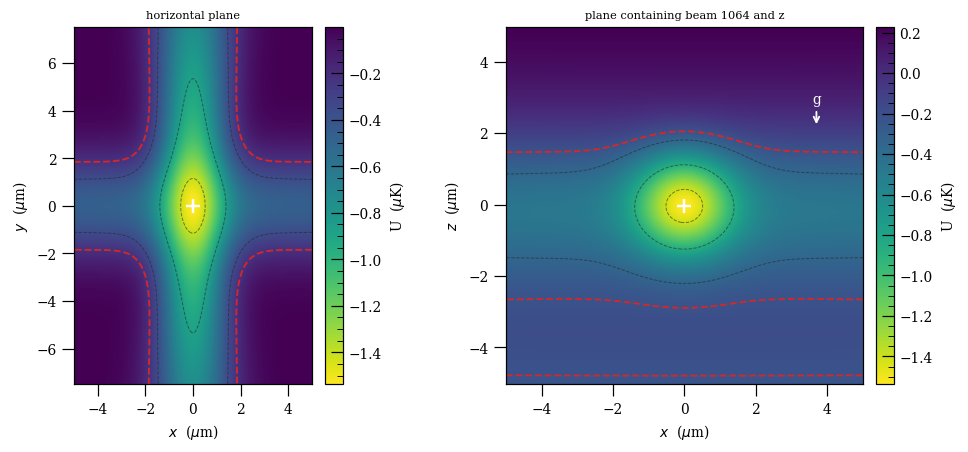

TrapCloud (gp): N = 2000, a = +10.969 a0
  grid TrapGrid(80x140x72, +-(1.84, 3.34, 1.73) um), normalization error -2.2e-16
  (mu - V_min)/h = 5161.006 Hz, (E/N - V_min)/h = 4273.544 Hz
  centroid (-0.0000, +0.0000, -0.0421) um, sigma (0.2954, 0.5328, 0.2763) um
  n0 = 2.1619e+15 cm^-3, peak column 1.8470e+11 cm^-2
  healing length 0.1781 um, Thomas-Fermi NOT valid here


In [ ]:
a = Tweezer(waist=3e-6, wavelength_m=1064e-9, power=50e-6, propagation_direction=(1, 0, 0),
            polarization=(0, 0, 1), label="1064")
# b = Tweezer(waist=2e-6, wavelength_m=1070e-9, power=50e-6, propagation_direction=(0, 1, 0),
#             polarization=(0, 0, 1), label="1070")
crossed = Trap(a, state=STATE, B_gauss=B_GAUSS, B_direction=B_DIR)
print(crossed.summary())
print("\nprincipal axes (rows):\n", crossed.principal_axes)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
tplt.plot_plane_cut(crossed, normal=(0, 0, 1), ax=axes[0], units="uK", title="horizontal plane")
tplt.plot_plane_cut(crossed, normal=(0, 1, 0), ax=axes[1], units="uK", title="plane containing beam 1064 and z")
plt.show()

cross_cloud = solve(crossed, 2000, "gp", points_per_scale=3.0)
print(cross_cloud.summary())

## Approximations, and what is not here yet

* Fundamental Gaussian modes, paraxial: no Gouy phase, no wavefront curvature, no longitudinal field
  (a NA-0.5 tweezer's polarization is ~10% non-transverse). Beams add incoherently.
* Second-order AC Stark shift only; the field is uniform (its direction is the quantization axis, it exerts no force),
  and $|F, m_F\rangle$ is the right basis only while the Zeeman splitting dominates the vector light shift.
* Zero temperature. Finite $T$ is the next step: `TrapCloud` already carries `T_K`, `condensate_fraction`
  and `density_thermal`; the Thomas-Fermi and GP solvers take a `V_extra` (for $2 g n_{\rm th}$ in a
  Popov / Hartree-Fock loop); the non-interacting solver keeps its excited states for a Boltzmann sum.